# Publication figures: renewable-following AI spot compute

This notebook is **plotting and analysis only**. It does not rerun CPLEX, simulated annealing, or D-Wave.
It reads the archived CAISO/Alibaba/Emerald calibration tables and the completed solver results from `data/`, then writes vector PDF figures to `figures/`.

The notebook is intentionally self-contained for an Overleaf workflow. Run it from the package root.

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

ROOT = Path.cwd()
DATA = ROOT / "data"
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)

matplotlib.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.linewidth": 2.4,
    "axes.labelpad": 8.0,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 3.1,
    "lines.markersize": 10,
    "lines.solid_capstyle": "round",
    "lines.dash_capstyle": "round",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
    "xtick.major.size": 6.0,
    "ytick.major.size": 6.0,
    "legend.fontsize": 12,
    "legend.title_fontsize": 13,
    "legend.frameon": True,
    "legend.framealpha": 0.94,
    "legend.edgecolor": "#444444",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "figure.dpi": 180,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "axes.facecolor": "white",
})

summary = pd.read_csv(DATA / "dwave_hybrid_summary.csv")
bench = pd.read_csv(DATA / "revised_solver_benchmark.csv")
compare = pd.read_csv(DATA / "dwave_vs_existing_baselines.csv")
profiles = pd.read_csv(DATA / "event_profiles_long.csv", parse_dates=["timestamp"])
events = pd.read_csv(DATA / "selected_caiso_events.csv", parse_dates=["start", "end"])
portfolio = pd.read_csv(DATA / "benchmark_spot_jobs_dvfs.csv")
cal = pd.read_csv(DATA / "emerald_dvfs_calibration.csv")
base_traj = pd.read_csv(DATA / "revised_solver_trajectories.csv", parse_dates=["timestamp"])
dw_traj = pd.read_csv(DATA / "dwave_all_trajectories.csv", parse_dates=["timestamp"])
chosen = pd.read_csv(DATA / "dwave_all_chosen_variables.csv")
manifest = json.loads((DATA / "revised_data_and_qubo_manifest.json").read_text())
campaign = json.loads((DATA / "campaign_config.json").read_text())

print(f"D-Wave events: {len(summary)}")
print(f"QUBO: {manifest['qubo_variables']} variables, {manifest['qubo_edges']:,} edges, density={100*manifest['qubo_density']:.2f}%")
print(f"Mean D-Wave objective: {summary.objective_direct.mean():.6f}")
print(f"Mean tracking RMSE: {summary.tracking_RMSE_kW.mean():.3f} kW")
print(f"Mean QPU access: {summary.qpu_access_time_s.mean():.3f} s")
print(f"Total QPU access: {summary.qpu_access_time_s.sum():.3f} s")


D-Wave events: 20
QUBO: 945 variables, 419,814 edges, density=94.12%
Mean D-Wave objective: 0.011607
Mean tracking RMSE: 0.511 kW
Mean QPU access: 1.610 s
Total QPU access: 32.193 s


## Figure 1: real CAISO event shapes mapped to the field-calibrated cluster envelope

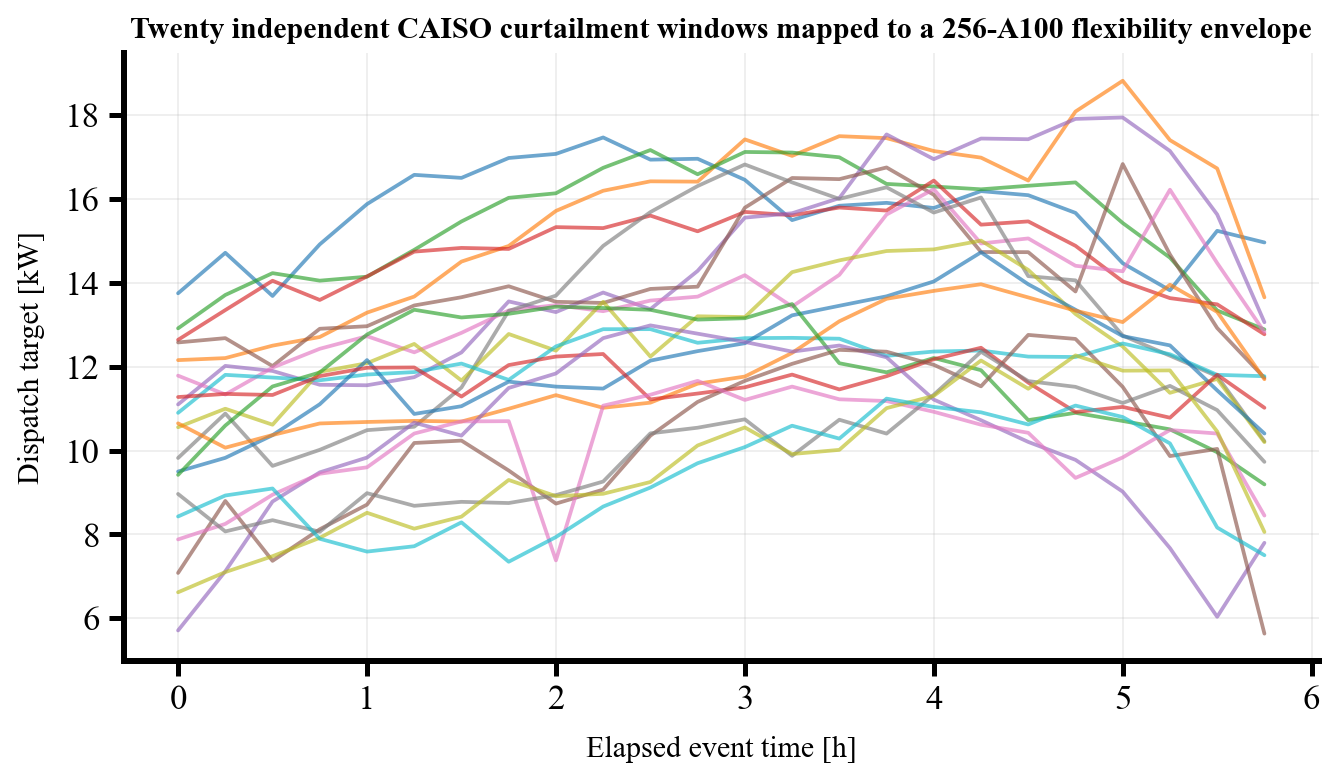

In [3]:
fig, ax = plt.subplots(figsize=(7.6, 4.5))
for eid, g in profiles.groupby("event_id"):
    g = g.sort_values("slot")
    ax.plot(g["slot"] * 0.25, g["dispatch_target_kW"], linewidth=1.5, alpha=0.65)
ax.set_xlabel("Elapsed event time [h]")
ax.set_ylabel("Dispatch target [kW]")
ax.set_title("Twenty independent CAISO curtailment windows mapped to a 256-A100 flexibility envelope")
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIG / "fig1_caiso_dispatch_targets.pdf", bbox_inches="tight")
plt.show()


## Figure 2: empirical Alibaba Spot-job portfolio

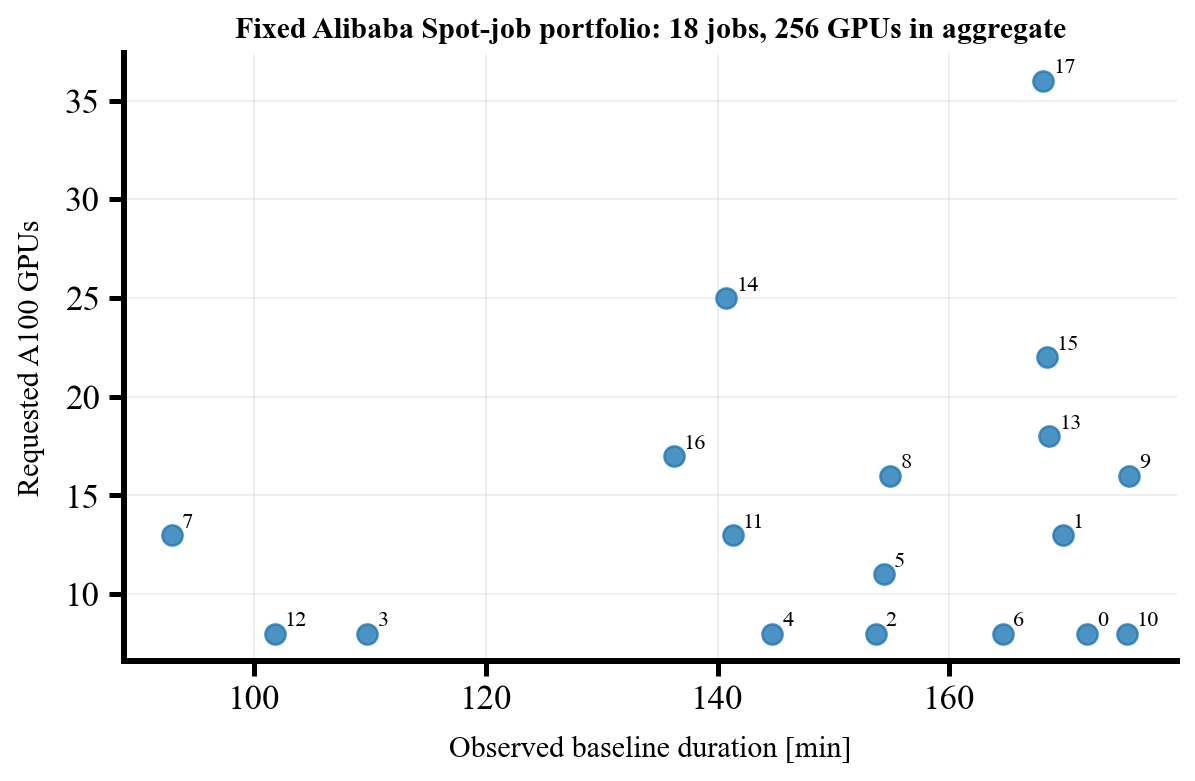

In [29]:
fig, ax = plt.subplots(figsize=(6.8, 4.5))
ax.scatter(portfolio["duration_minutes"], portfolio["total_gpus"], s=65, alpha=0.8)
for r in portfolio.itertuples():
    ax.annotate(str(int(r.portfolio_job_id)), (r.duration_minutes, r.total_gpus), xytext=(4, 3), textcoords="offset points", fontsize=9)
ax.set_xlabel("Observed baseline duration [min]")
ax.set_ylabel("Requested A100 GPUs")
ax.set_title(f"Fixed Alibaba Spot-job portfolio: {len(portfolio)} jobs, {int(portfolio.total_gpus.sum())} GPUs in aggregate")
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIG / "fig2_alibaba_spot_portfolio.pdf", bbox_inches="tight")
plt.show()


## Figure 3: field-measured A100 DVFS power-performance calibration

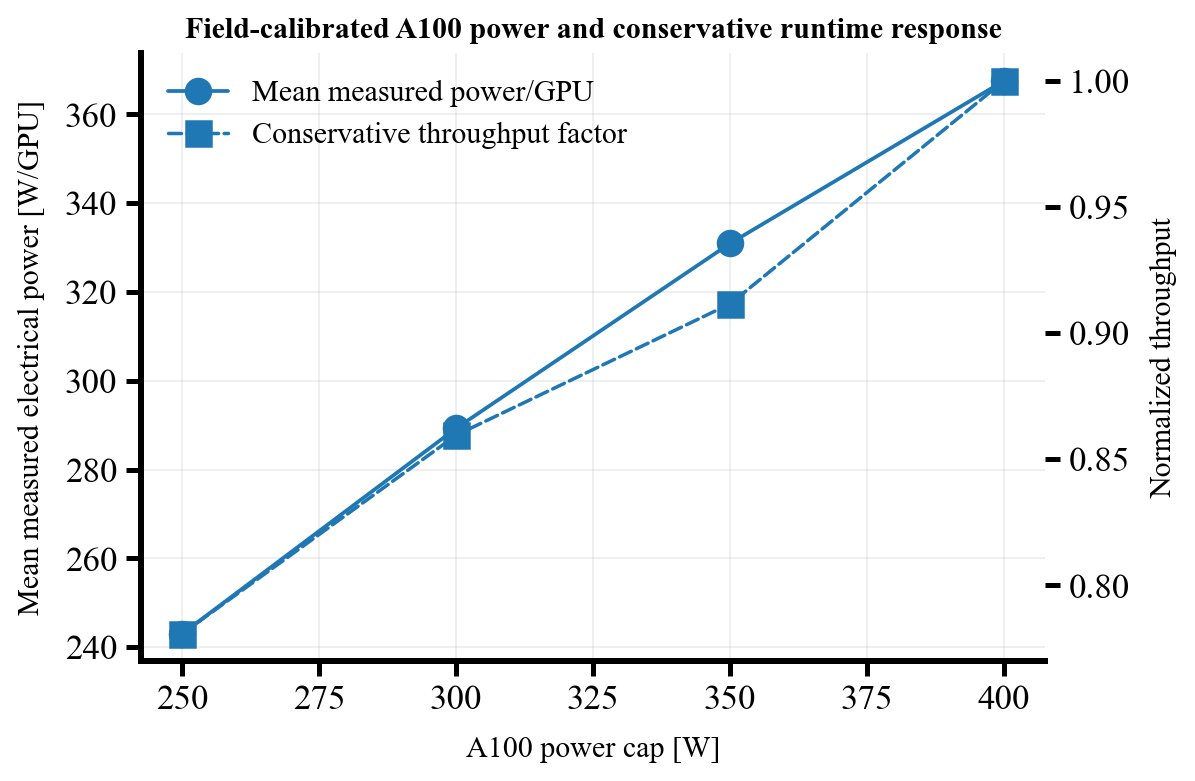

In [30]:
fig, ax = plt.subplots(figsize=(6.8, 4.5))
ax.plot(cal["power_cap_W"], cal["power_per_gpu_W_mean"], marker="o", linewidth=1.5, label="Mean measured power/GPU")
ax.set_xlabel("A100 power cap [W]")
ax.set_ylabel("Mean measured electrical power [W/GPU]")
ax2 = ax.twinx()
ax2.plot(cal["power_cap_W"], cal["model_throughput_factor"], marker="s", linestyle="--", linewidth=1.4, label="Conservative throughput factor")
ax2.set_ylabel("Normalized throughput")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, frameon=False, loc="best")
ax.set_title("Field-calibrated A100 power and conservative runtime response")
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIG / "fig3_field_dvfs_calibration.pdf", bbox_inches="tight")
plt.show()


## Figure 4: representative hard event, same physical target across all solvers

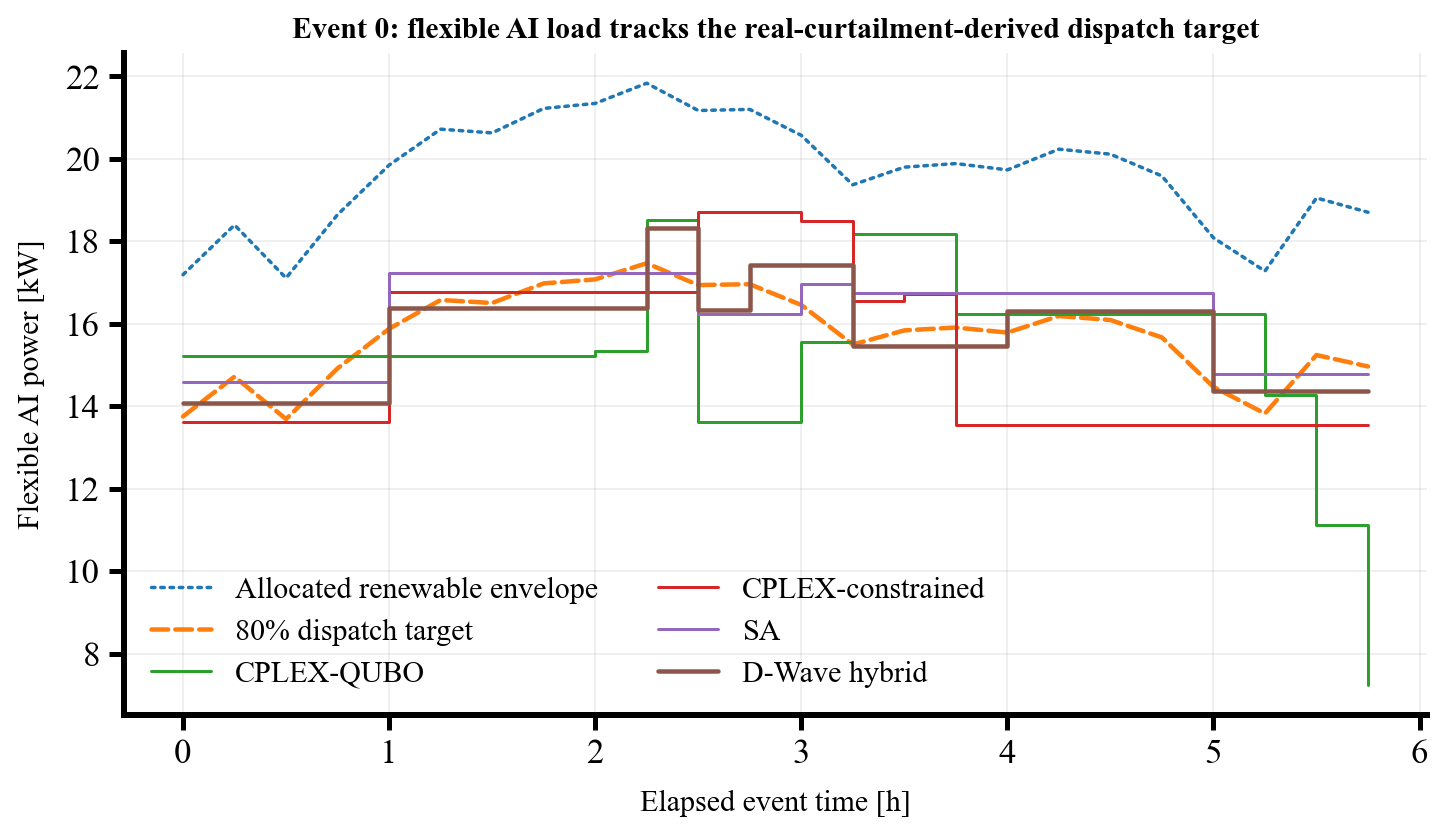

In [31]:
eid = 0
p = profiles[profiles.event_id == eid].sort_values("slot")
b = base_traj[base_traj.event_id == eid]
d = dw_traj[dw_traj.event_id == eid].sort_values("slot")

fig, ax = plt.subplots(figsize=(8.2, 4.8))
hours = p["slot"].to_numpy() * 0.25
ax.plot(hours, p["allocated_curtailment_kW"], linestyle=":", linewidth=1.4, label="Allocated renewable envelope")
ax.plot(hours, p["dispatch_target_kW"], linestyle="--", linewidth=1.8, label="80% dispatch target")
for method in ["CPLEX-QUBO", "CPLEX-constrained", "SA"]:
    g = b[b.method == method].sort_values("slot")
    ax.step(hours, g["gpu_load_kW"], where="post", linewidth=1.2, label=method)
ax.step(hours, d["dwave_gpu_load_kW"], where="post", linewidth=1.8, label="D-Wave hybrid")
ax.set_xlabel("Elapsed event time [h]")
ax.set_ylabel("Flexible AI power [kW]")
ax.set_title("Event 0: flexible AI load tracks the real-curtailment-derived dispatch target")
ax.legend(frameon=False, ncol=2)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIG / "fig4_event0_solver_tracking.pdf", bbox_inches="tight")
plt.show()


## Figure 5: objective quality on the three pre-specified benchmark events

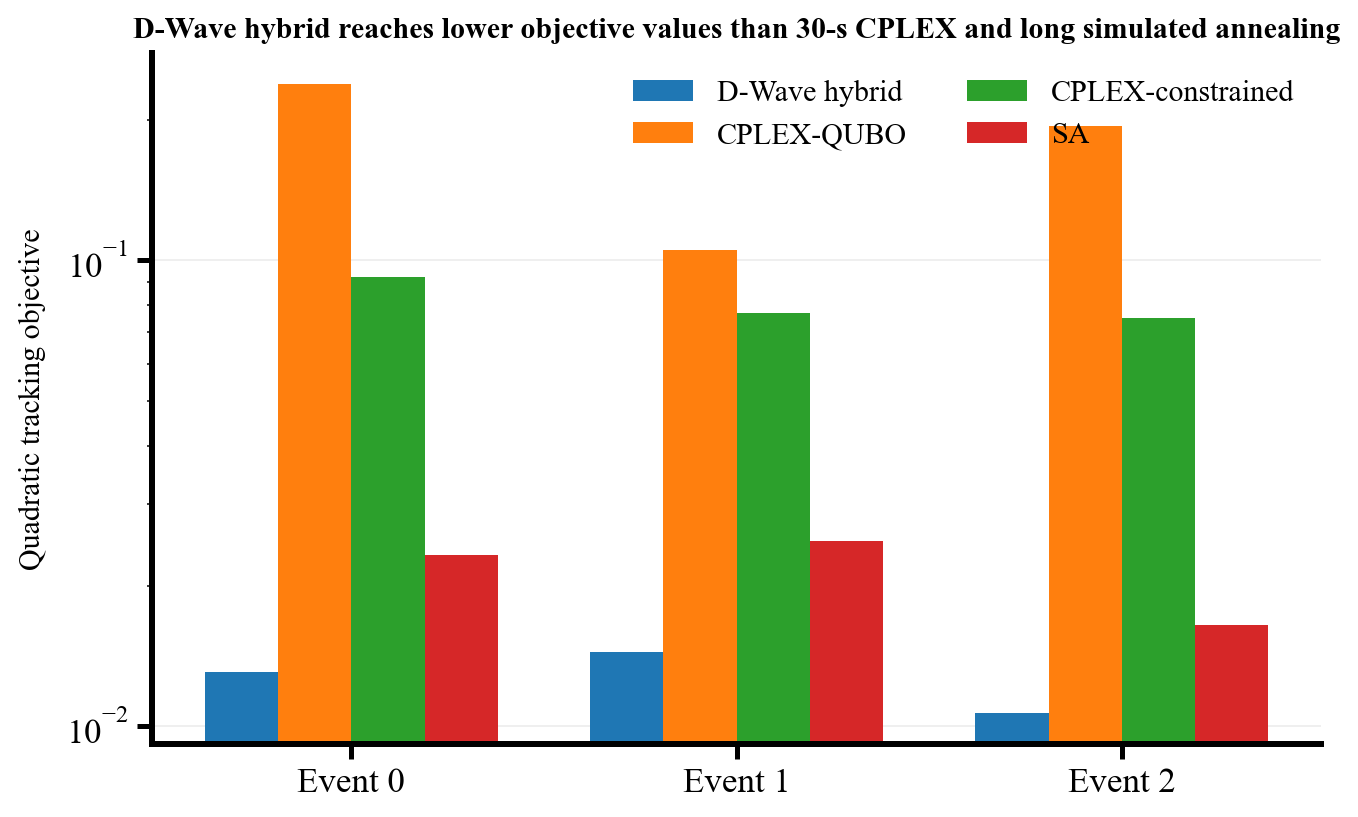

In [32]:
plot = bench.pivot(index="event_id", columns="method", values="objective_direct").loc[[0,1,2]]
plot["D-Wave hybrid"] = summary.set_index("event_id").loc[[0,1,2], "objective_direct"]
order = ["D-Wave hybrid", "CPLEX-QUBO", "CPLEX-constrained", "SA"]

fig, ax = plt.subplots(figsize=(7.6, 4.7))
x = np.arange(3)
width = 0.19
for k, method in enumerate(order):
    ax.bar(x + (k-1.5)*width, plot[method].to_numpy(), width, label=method)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(["Event 0", "Event 1", "Event 2"])
ax.set_ylabel("Quadratic tracking objective")
ax.set_title("D-Wave hybrid reaches lower objective values than 30-s CPLEX and long simulated annealing")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIG / "fig5_solver_objective_benchmark.pdf", bbox_inches="tight")
plt.show()


## Figure 6: tracking-error comparison for the three benchmark events

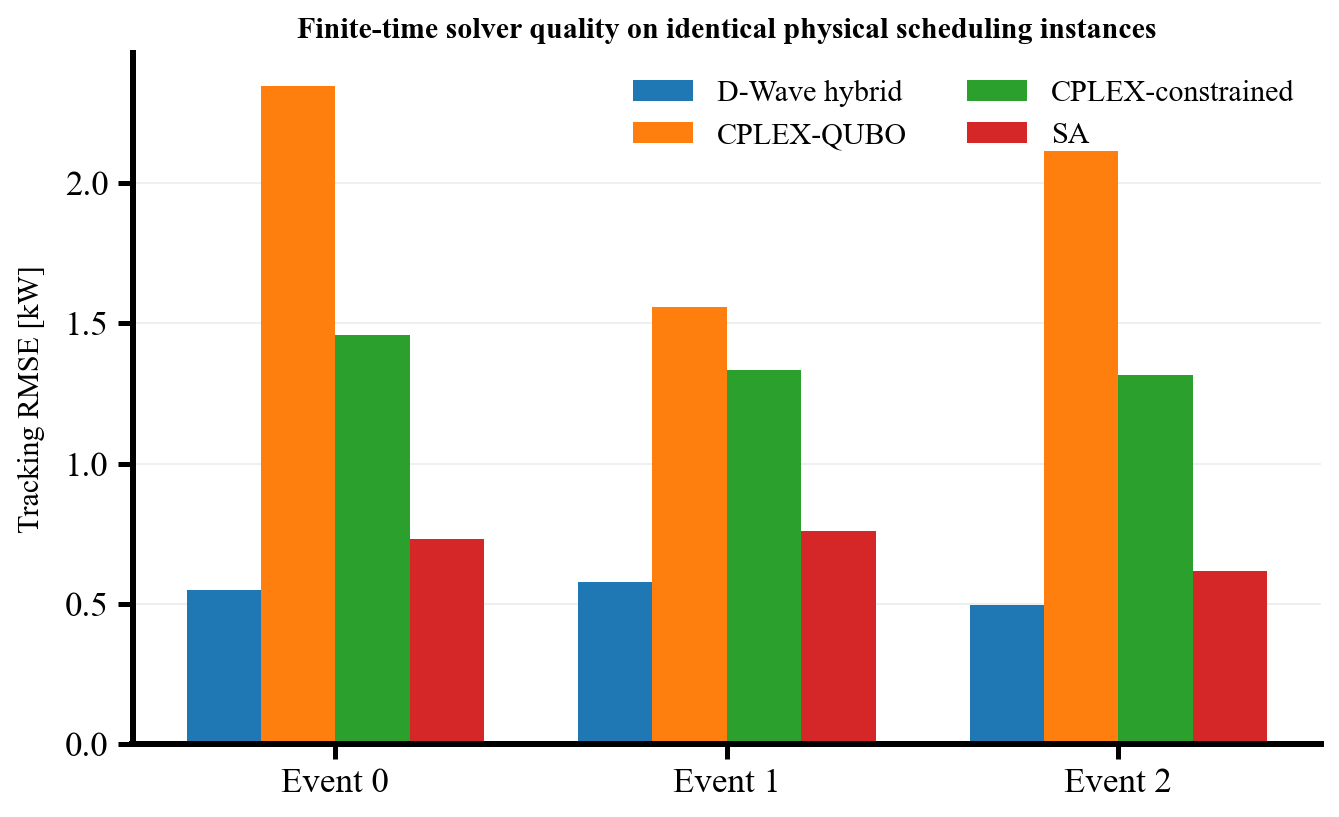

In [33]:
plot = bench.pivot(index="event_id", columns="method", values="tracking_RMSE_kW").loc[[0,1,2]]
plot["D-Wave hybrid"] = summary.set_index("event_id").loc[[0,1,2], "tracking_RMSE_kW"]
order = ["D-Wave hybrid", "CPLEX-QUBO", "CPLEX-constrained", "SA"]

fig, ax = plt.subplots(figsize=(7.6, 4.7))
x = np.arange(3)
width = 0.19
for k, method in enumerate(order):
    ax.bar(x + (k-1.5)*width, plot[method].to_numpy(), width, label=method)
ax.set_xticks(x)
ax.set_xticklabels(["Event 0", "Event 1", "Event 2"])
ax.set_ylabel("Tracking RMSE [kW]")
ax.set_title("Finite-time solver quality on identical physical scheduling instances")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIG / "fig6_solver_tracking_rmse.pdf", bbox_inches="tight")
plt.show()


## Figure 7: D-Wave robustness across all twenty independent events

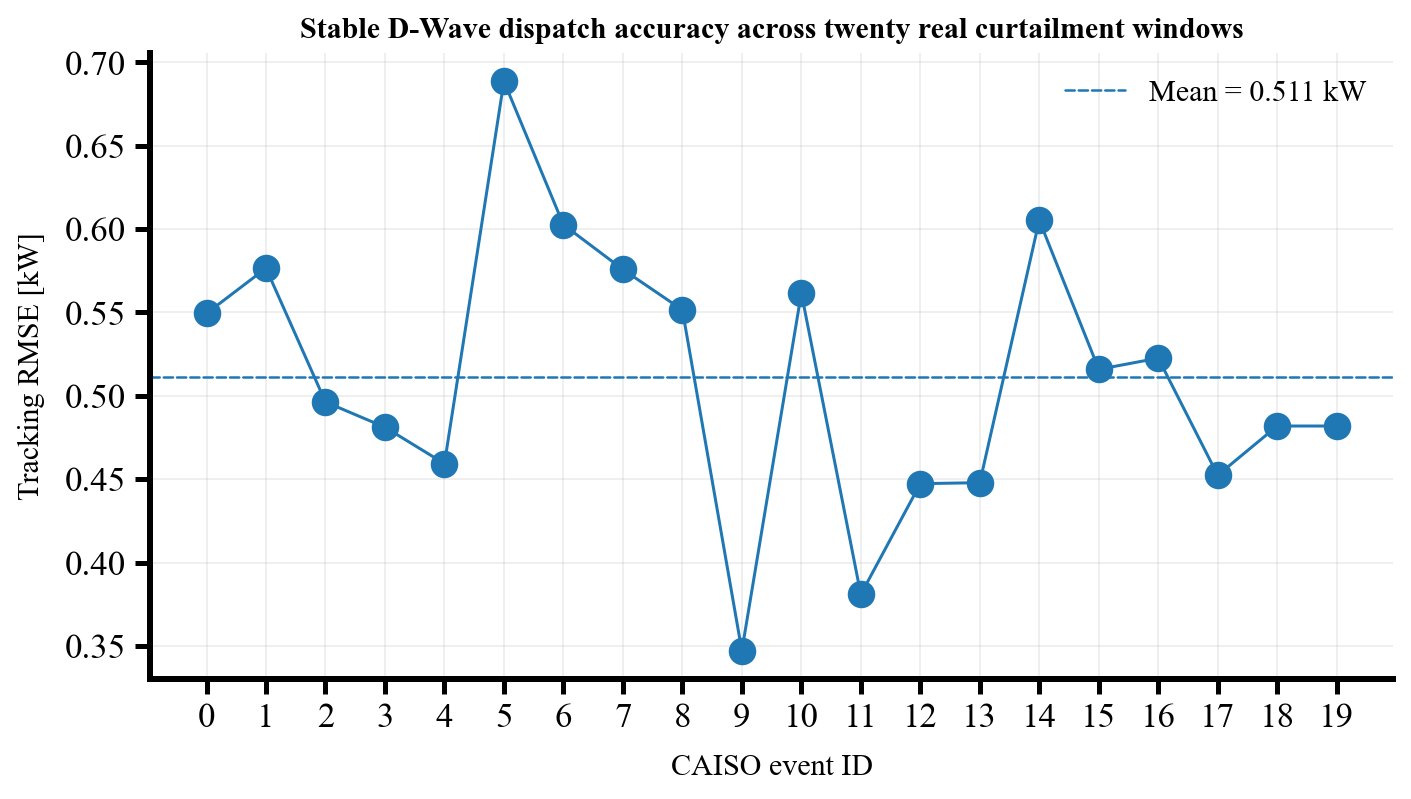

In [34]:
fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.plot(summary["event_id"], summary["tracking_RMSE_kW"], marker="o", linewidth=1.2)
ax.axhline(summary["tracking_RMSE_kW"].mean(), linestyle="--", linewidth=1.0, label=f"Mean = {summary.tracking_RMSE_kW.mean():.3f} kW")
ax.set_xlabel("CAISO event ID")
ax.set_ylabel("Tracking RMSE [kW]")
ax.set_title("Stable D-Wave dispatch accuracy across twenty real curtailment windows")
ax.set_xticks(np.arange(20))
ax.legend(frameon=False)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIG / "fig7_dwave_20event_rmse.pdf", bbox_inches="tight")
plt.show()


## Figure 8: energy matching and curtailment-envelope capture across twenty events

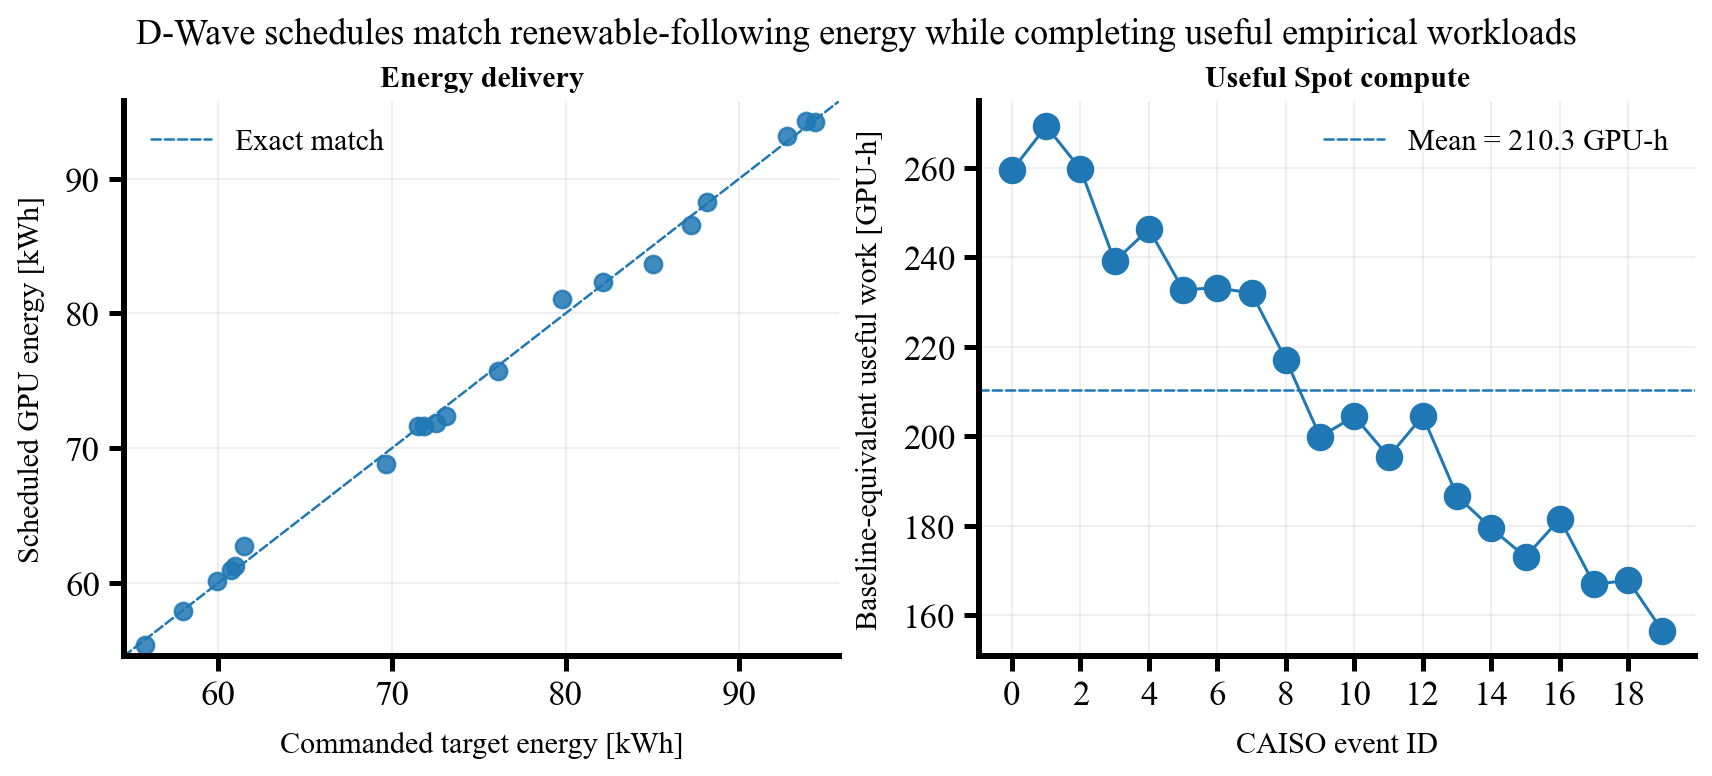

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.2), constrained_layout=True)

# (a) Event-energy fidelity
x = summary["target_energy_kWh"].to_numpy()
y = summary["scheduled_gpu_energy_kWh"].to_numpy()
axes[0].scatter(x, y, s=48, alpha=0.85)
lo = min(x.min(), y.min()) * 0.985
hi = max(x.max(), y.max()) * 1.015
axes[0].plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.0, label="Exact match")
axes[0].set_xlim(lo, hi)
axes[0].set_ylim(lo, hi)
axes[0].set_xlabel("Commanded target energy [kWh]")
axes[0].set_ylabel("Scheduled GPU energy [kWh]")
axes[0].set_title("Energy delivery")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.2)

# (b) Useful empirical work admitted
axes[1].plot(summary["event_id"], summary["completed_baseline_gpu_hours"], marker="o", linewidth=1.2)
axes[1].axhline(summary["completed_baseline_gpu_hours"].mean(), linestyle="--", linewidth=1.0,
                label=f"Mean = {summary.completed_baseline_gpu_hours.mean():.1f} GPU-h")
axes[1].set_xlabel("CAISO event ID")
axes[1].set_ylabel("Baseline-equivalent useful work [GPU-h]")
axes[1].set_title("Useful Spot compute")
axes[1].set_xticks(np.arange(0, 20, 2))
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.2)

fig.suptitle("D-Wave schedules match renewable-following energy while completing useful empirical workloads")
fig.savefig(FIG / "fig8_dwave_energy_matching.pdf", bbox_inches="tight")
plt.show()


## Figure 9: hybrid runtime and QPU participation

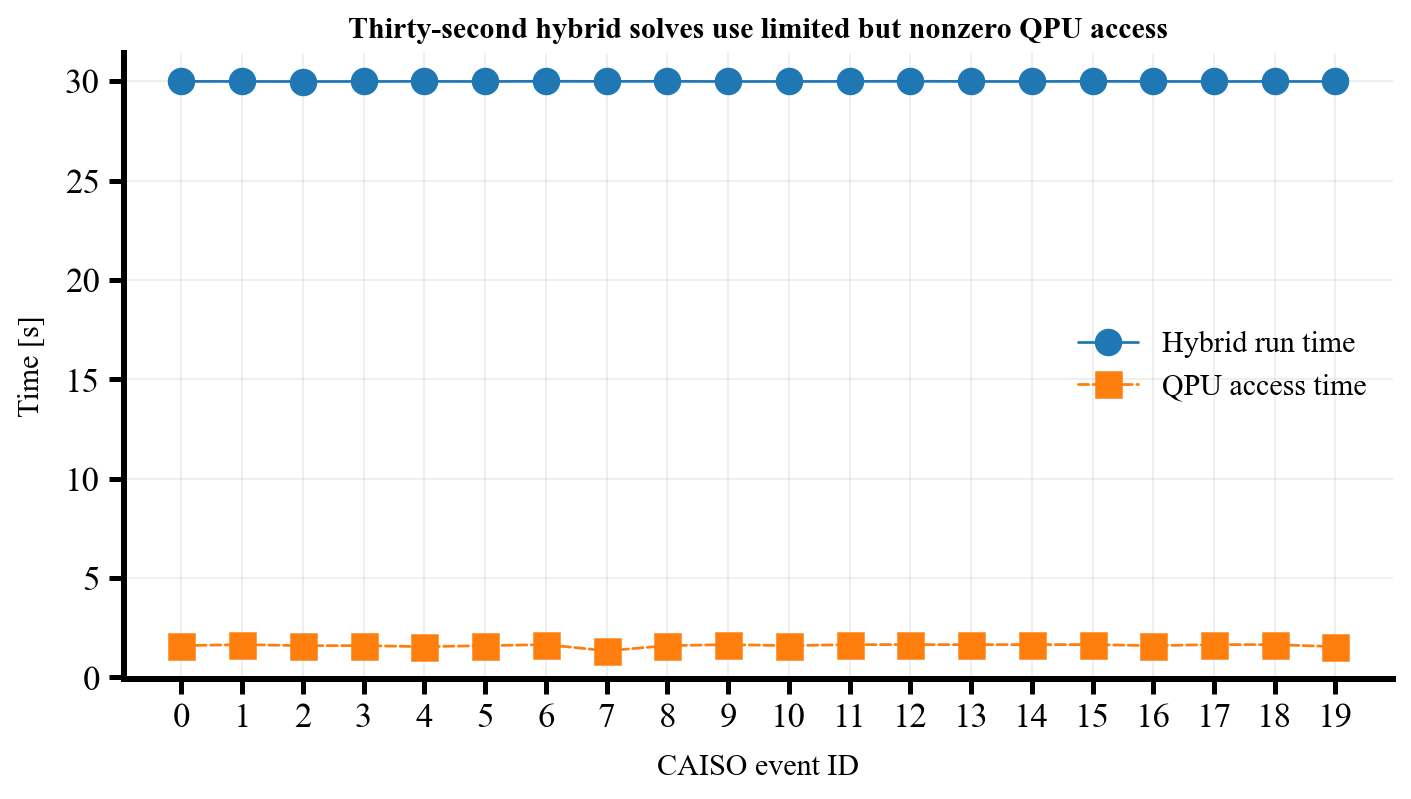

In [36]:
fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.plot(summary["event_id"], summary["run_time_s"], marker="o", linewidth=1.1, label="Hybrid run time")
ax.plot(summary["event_id"], summary["qpu_access_time_s"], marker="s", linestyle="--", linewidth=1.1, label="QPU access time")
ax.set_xlabel("CAISO event ID")
ax.set_ylabel("Time [s]")
ax.set_title("Thirty-second hybrid solves use limited but nonzero QPU access")
ax.set_xticks(np.arange(20))
ax.legend(frameon=False)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIG / "fig9_dwave_hybrid_timing.pdf", bbox_inches="tight")
plt.show()


## Figure 10: DVFS choices across the twenty D-Wave schedules

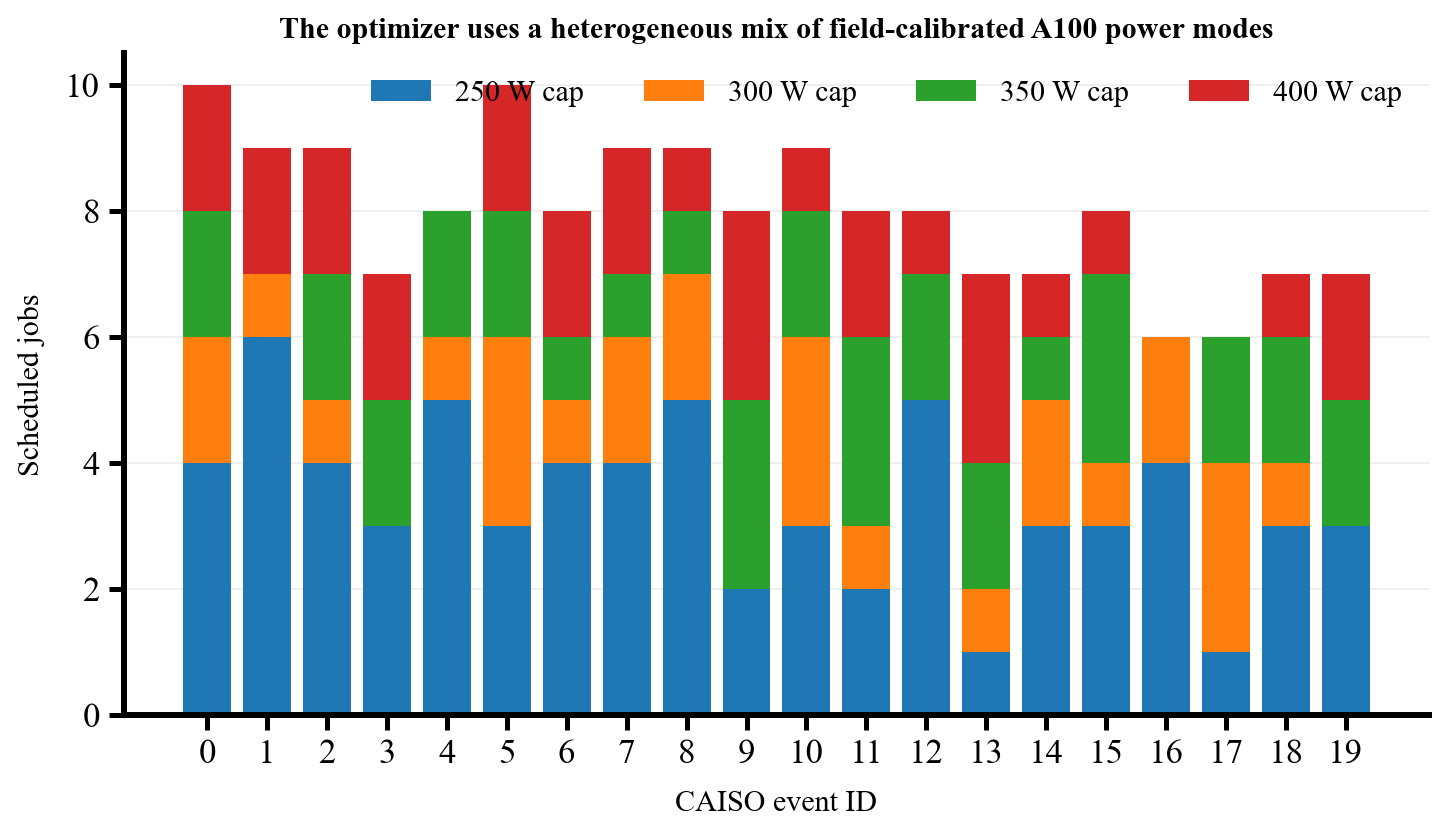

In [37]:
fig, ax = plt.subplots(figsize=(8.2, 4.8))
x = summary["event_id"].to_numpy()
bottom = np.zeros(len(summary))
for cap in [250, 300, 350, 400]:
    vals = summary[f"cap{cap}_jobs"].to_numpy()
    ax.bar(x, vals, bottom=bottom, label=f"{cap} W cap")
    bottom += vals
ax.set_xlabel("CAISO event ID")
ax.set_ylabel("Scheduled jobs")
ax.set_title("The optimizer uses a heterogeneous mix of field-calibrated A100 power modes")
ax.set_xticks(np.arange(20))
ax.legend(frameon=False, ncol=4)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIG / "fig10_dwave_dvfs_mix.pdf", bbox_inches="tight")
plt.show()


## Supplementary figure: audit of the single tiny envelope exceedance

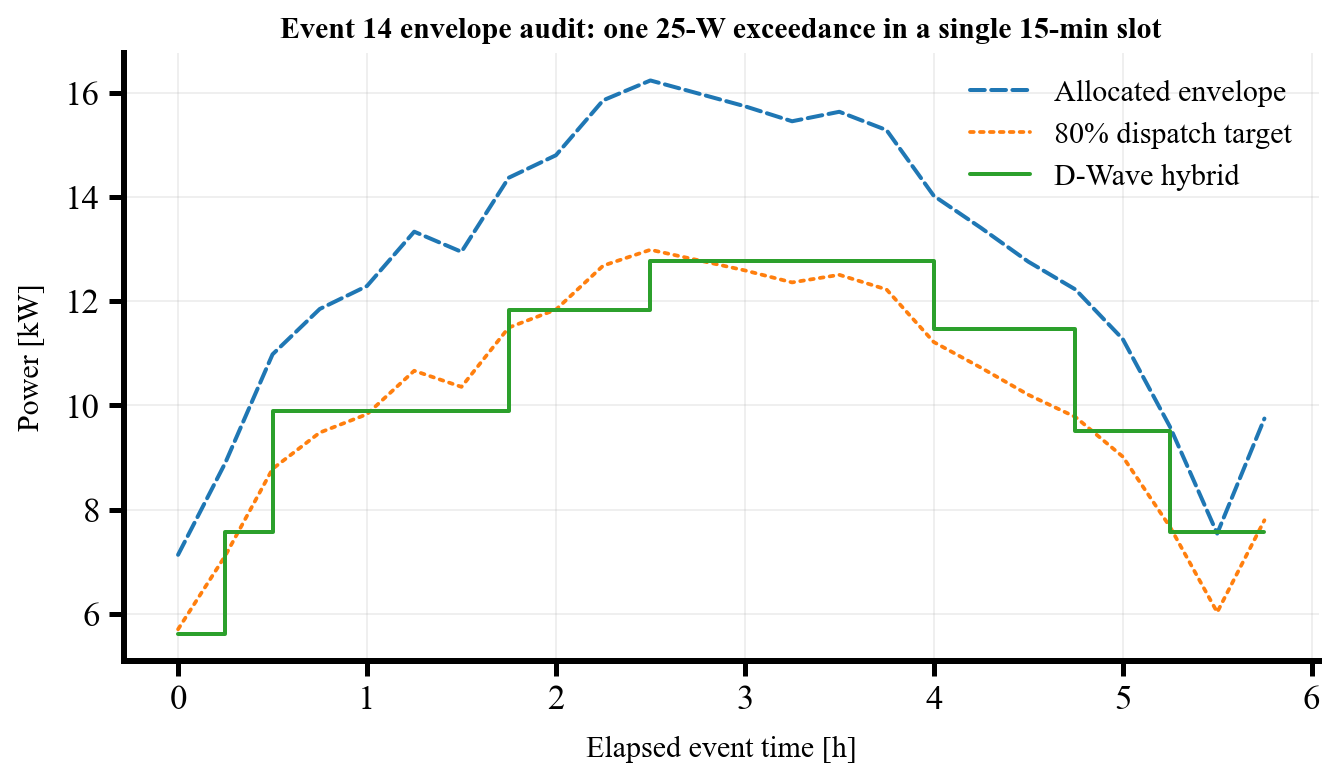

In [38]:
eid = 14
p = profiles[profiles.event_id == eid].sort_values("slot")
d = dw_traj[dw_traj.event_id == eid].sort_values("slot")
hours = p["slot"].to_numpy() * 0.25

fig, ax = plt.subplots(figsize=(7.6, 4.5))
ax.plot(hours, p["allocated_curtailment_kW"], linestyle="--", linewidth=1.6, label="Allocated envelope")
ax.plot(hours, p["dispatch_target_kW"], linestyle=":", linewidth=1.5, label="80% dispatch target")
ax.step(hours, d["dwave_gpu_load_kW"], where="post", linewidth=1.6, label="D-Wave hybrid")
ax.set_xlabel("Elapsed event time [h]")
ax.set_ylabel("Power [kW]")
ax.set_title("Event 14 envelope audit: one 25-W exceedance in a single 15-min slot")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIG / "figS1_event14_envelope_audit.pdf", bbox_inches="tight")
plt.show()


## Export publication summary tables

In [39]:
aggregate = pd.DataFrame({
    "metric": [
        "D-Wave objective", "Tracking RMSE [kW]", "Target-energy ratio",
        "Envelope capture fraction", "Scheduled jobs", "Baseline-equivalent GPU-hours",
        "Peak concurrent GPUs", "Hybrid run time [s]", "QPU access time [s]"
    ],
    "mean": [
        summary.objective_direct.mean(), summary.tracking_RMSE_kW.mean(), summary.target_energy_ratio.mean(),
        summary.capture_fraction_of_envelope.mean(), summary.n_jobs_scheduled.mean(), summary.completed_baseline_gpu_hours.mean(),
        summary.max_concurrent_gpus.mean(), summary.run_time_s.mean(), summary.qpu_access_time_s.mean()
    ],
    "std": [
        summary.objective_direct.std(), summary.tracking_RMSE_kW.std(), summary.target_energy_ratio.std(),
        summary.capture_fraction_of_envelope.std(), summary.n_jobs_scheduled.std(), summary.completed_baseline_gpu_hours.std(),
        summary.max_concurrent_gpus.std(), summary.run_time_s.std(), summary.qpu_access_time_s.std()
    ],
    "min": [
        summary.objective_direct.min(), summary.tracking_RMSE_kW.min(), summary.target_energy_ratio.min(),
        summary.capture_fraction_of_envelope.min(), summary.n_jobs_scheduled.min(), summary.completed_baseline_gpu_hours.min(),
        summary.max_concurrent_gpus.min(), summary.run_time_s.min(), summary.qpu_access_time_s.min()
    ],
    "max": [
        summary.objective_direct.max(), summary.tracking_RMSE_kW.max(), summary.target_energy_ratio.max(),
        summary.capture_fraction_of_envelope.max(), summary.n_jobs_scheduled.max(), summary.completed_baseline_gpu_hours.max(),
        summary.max_concurrent_gpus.max(), summary.run_time_s.max(), summary.qpu_access_time_s.max()
    ],
})
aggregate.to_csv(DATA / "publication_aggregate_statistics.csv", index=False)
compare.to_csv(DATA / "publication_solver_comparison.csv", index=False)
display(aggregate)


,metric,mean,std,min,max
0,D-Wave objective,0.011607,0.003613,0.005225,0.020567
1,Tracking RMSE [kW],0.511318,0.080757,0.347114,0.688645
2,Target-energy ratio,0.999437,0.008895,0.983957,1.020456
3,Envelope capture fraction,0.799546,0.007106,0.787165,0.816283
4,Scheduled jobs,8.000000,1.169795,6.000000,10.000000
5,Baseline-equivalent GPU-hours,210.259333,34.603421,156.442778,269.340833
6,Peak concurrent GPUs,51.100000,9.623983,37.000000,70.000000
7,Hybrid run time [s],29.991657,0.003700,29.987324,29.999121
8,QPU access time [s],1.609654,0.071636,1.343600,1.653662
